In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import savefig

In [5]:
od = pd.read_csv("Order.csv",encoding='latin-1')
rt = pd.read_csv("Return.csv", encoding ='latin-1')
pp = pd.read_csv("People.csv", encoding='latin-1')

In [6]:
od.shape

(51290, 24)

In [7]:
rt.shape

(1079, 3)

In [8]:
pp.shape

(24, 2)

In [9]:
od.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   Postal Code     9994 non-null   float64
 9   City            51290 non-null  str    
 10  State           51290 non-null  str    
 11  Country         51290 non-null  str    
 12  Region          51290 non-null  str    
 13  Market          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [10]:
od.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,($288.77),923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless","$2,892.51",5,0.1,($96.54),910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.04,Critical
5,22732,IN-2014-JM156557-41818,6/28/2014,7/1/2014,Second Class,JM-156557,Jim Mitchum,Corporate,NaN,Sydney,...,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID","$2,862.68",5,0.1,$763.28,897.35,Critical
6,30570,IN-2012-TS2134092-41219,11/6/2012,11/8/2012,First Class,TS-2134092,Toby Swindell,Consumer,NaN,Porirua,...,FUR-CH-5378,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable","$1,822.08",4,0.0,$564.84,894.77,Critical
7,31192,IN-2013-MB1808592-41378,4/14/2013,4/18/2013,Standard Class,MB-1808592,Mick Brown,Consumer,NaN,Hamilton,...,FUR-TA-3764,Furniture,Tables,"Chromcraft Conference Table, Fully Assembled","$5,244.84",6,0.0,$996.48,878.38,High
8,40099,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,FUR-BO-5957,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",$341.96,2,0.0,$54.71,25.27,High
9,36258,CA-2012-AB10015140-40974,3/6/2012,3/7/2012,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,FUR-CH-4421,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",$48.71,1,0.2,$5.48,11.13,High


In [11]:
od.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [12]:
od.duplicated().sum()

np.int64(0)

In [13]:
od['Order Date'] = pd.to_datetime(od['Order Date'])
od['Ship Date'] = pd.to_datetime(od['Ship Date'])

In [14]:
od['Year'] = od['Order Date'].dt.year
od['Month'] = od['Order Date'].dt.month



Làm sạch dữ liệu tiền

In [15]:
def clean_money(col):
    col = col.astype(str)
    col = col.str.replace('$', '', regex=False)
    col = col.str.replace(',', '', regex=False)
    col = col.str.replace('(', '-', regex=False)
    col = col.str.replace(')', '', regex=False)
    col = col.str.strip()
    return pd.to_numeric(col, errors='coerce')

for col in ['Sales', 'Profit', 'Shipping Cost']:
    od[col] = clean_money(od[col])

Biểu đồ histogram của biến S

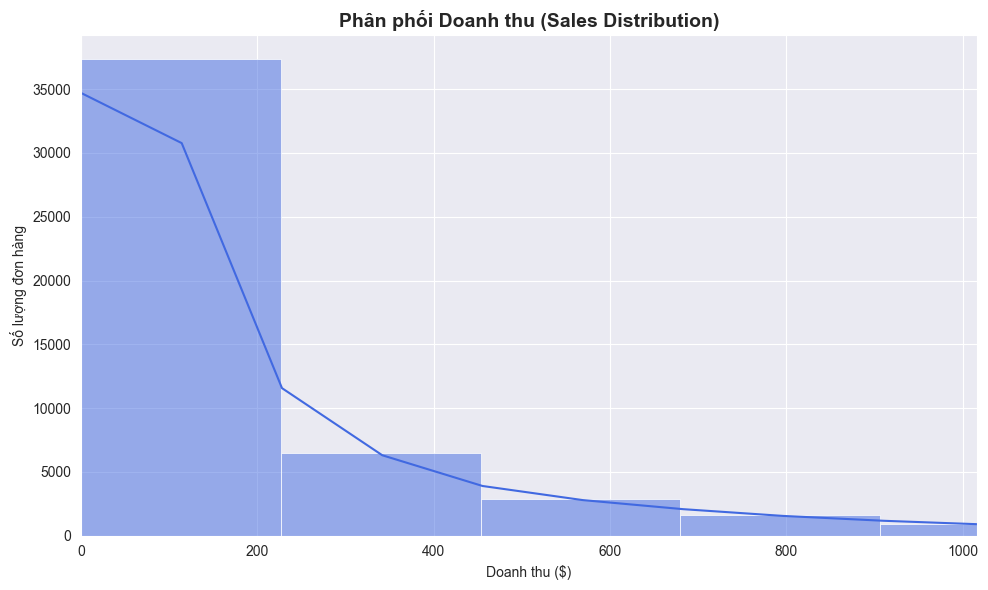

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Sales'], bins=100, kde=True, color='royalblue')
plt.title('Phân phối Doanh thu (Sales Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Sales'].quantile(0.95))
plt.tight_layout()
plt.savefig('histogram_sales.png', dpi=300)
plt.show()

Biểu đồ Histogram của Doanh thu cho thấy sự phân bố không đồng đều. Số lượng đơn hàng tập trung nhiều ở phân khúc có giá trị thấp( dưới 200$), trong khi các đơn hàng có giá trị cao (outliers) có số lượng rất ít kéo dài về phía bên phải.

Biểu đồ boxplot của biến S

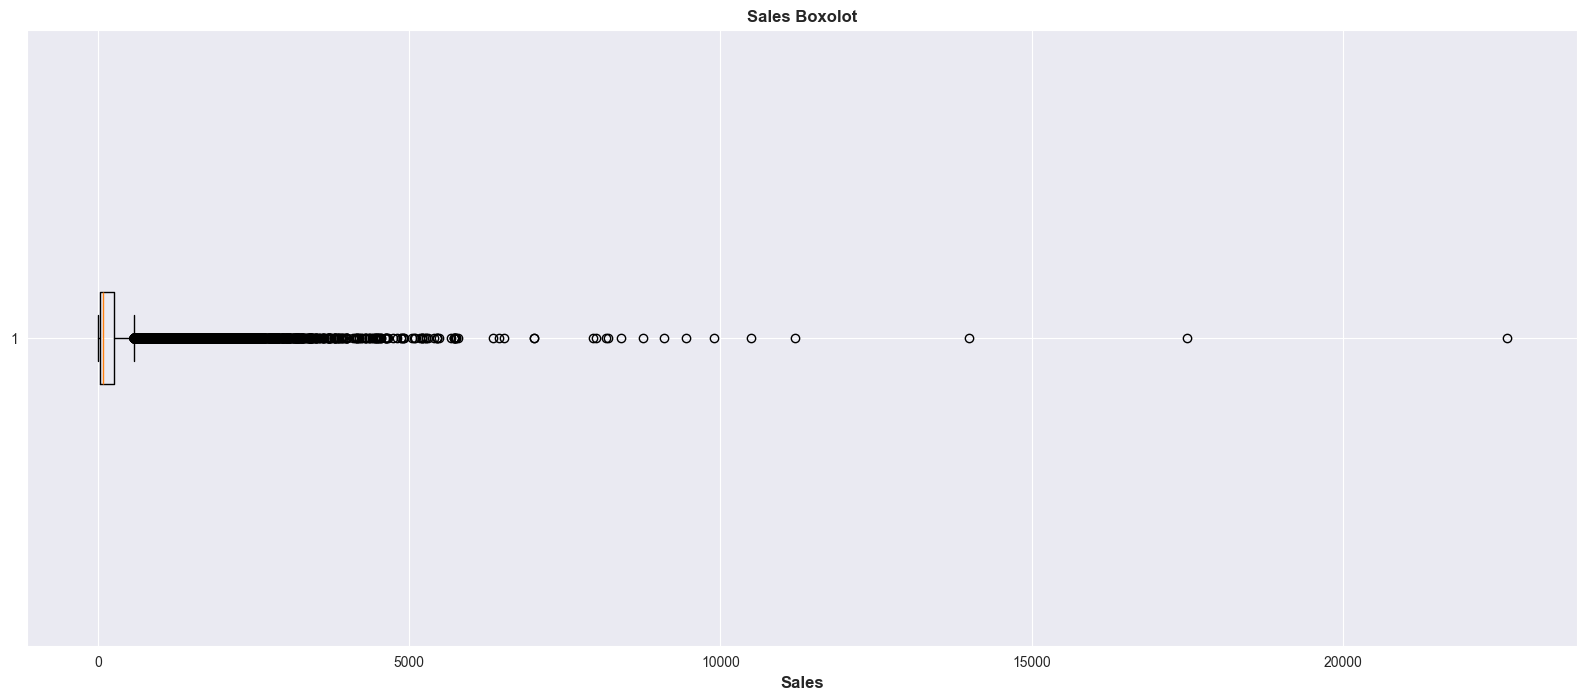

In [16]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Sales'],vert=False)
plt.title('Sales Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Sales', fontsize=12, fontweight='bold')
plt.show()

- Phân phối doanh thu có xu hướng lệch phải, với phần lớn đơn hàng có giá trị thấp.
- Một số ít đơn hàng có giá trị rất cao tạo ra nhiều outlier.

Biểu đồ histogram của biến P

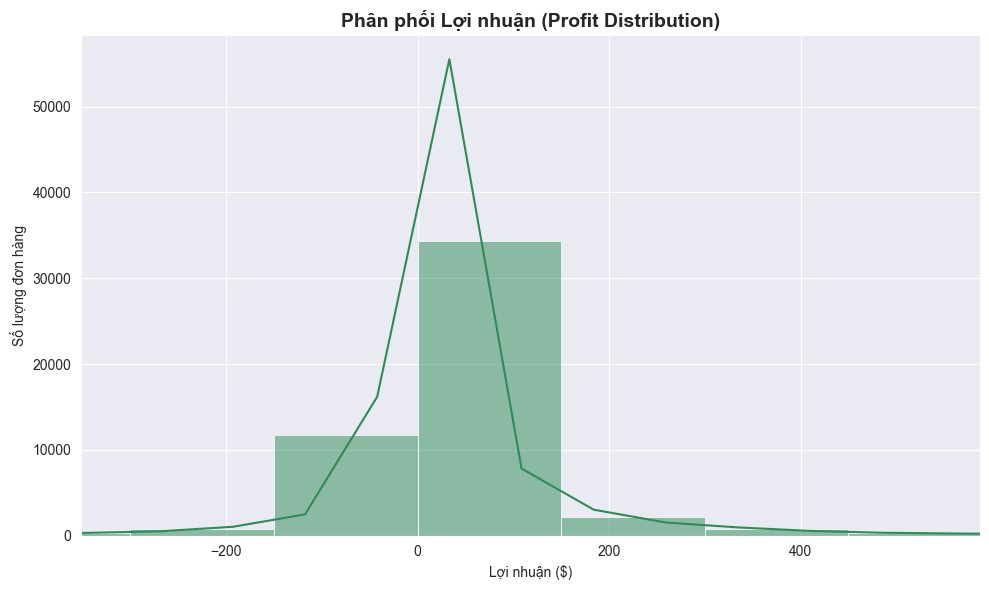

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Profit'], bins=100, kde=True, color='seagreen')
plt.title('Phân phối Lợi nhuận (Profit Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Lợi nhuận ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(od['Profit'].quantile(0.01), od['Profit'].quantile(0.99))
plt.tight_layout()
plt.savefig('histogram_profit.png', dpi=300)
plt.show()

- Đuôi bên trái rất dài cho thấy có nhiều đơn hàng thua lỗ nặng
- Các cột nhỏ bên phải đại diện cho nhóm sản phẩm siêu lợi nhuận.

Biểu đồ boxplot của biến P

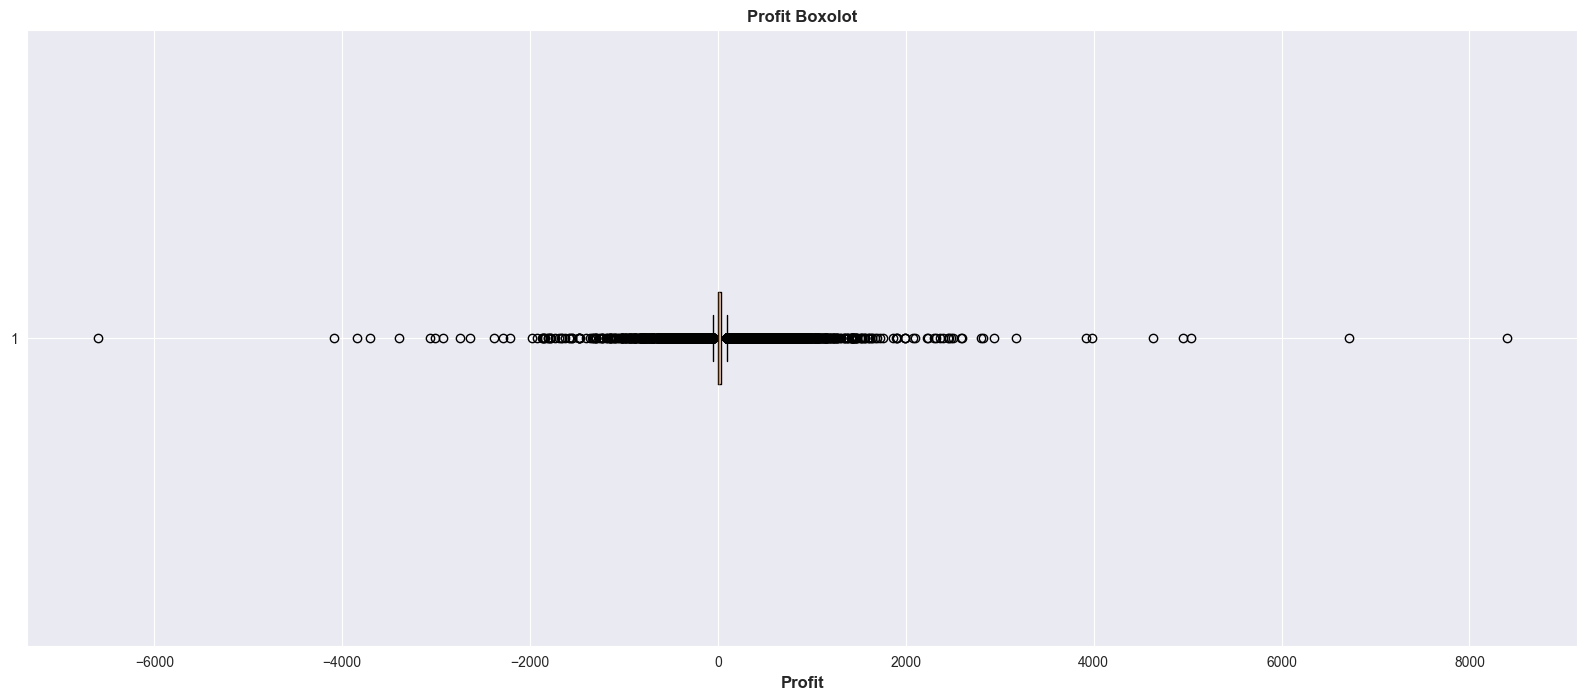

In [17]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Profit'],vert=False)
plt.title('Profit Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Profit', fontsize=12, fontweight='bold')
plt.show()

- Phần lớn đơn hàng có mức lợi nhuận thấp, gần như hòa vốn
- Xuất hiện nhiều outliers ở cả 2 phía cho thấy có sự chênh lệnh lớn về lợi nhuận.

Biểu đồ histogram của biến Shipping Cost

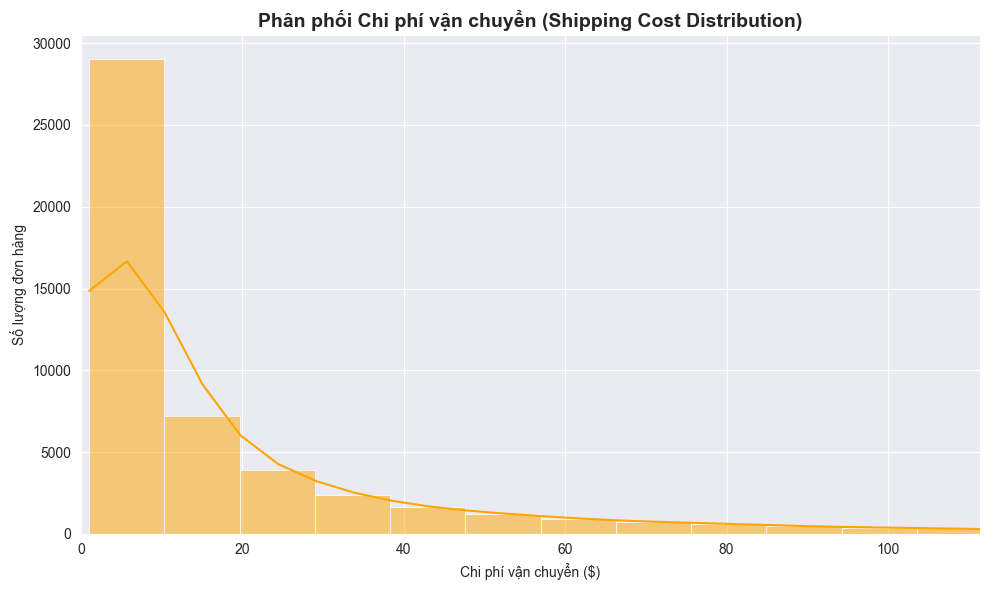

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Shipping Cost'], bins=100, kde=True, color='orange')
plt.title('Phân phối Chi phí vận chuyển (Shipping Cost Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Chi phí vận chuyển ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Shipping Cost'].quantile(0.95))
plt.tight_layout()
plt.savefig('histogram_shipping_cost.png', dpi=300)
plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển thấp
- Bên cạnh đó xuất hiện nhiều đơn hàng có giá trị vận chuyển cao, tăng đột b

Biểu đồ boxplot của biến Shipping C

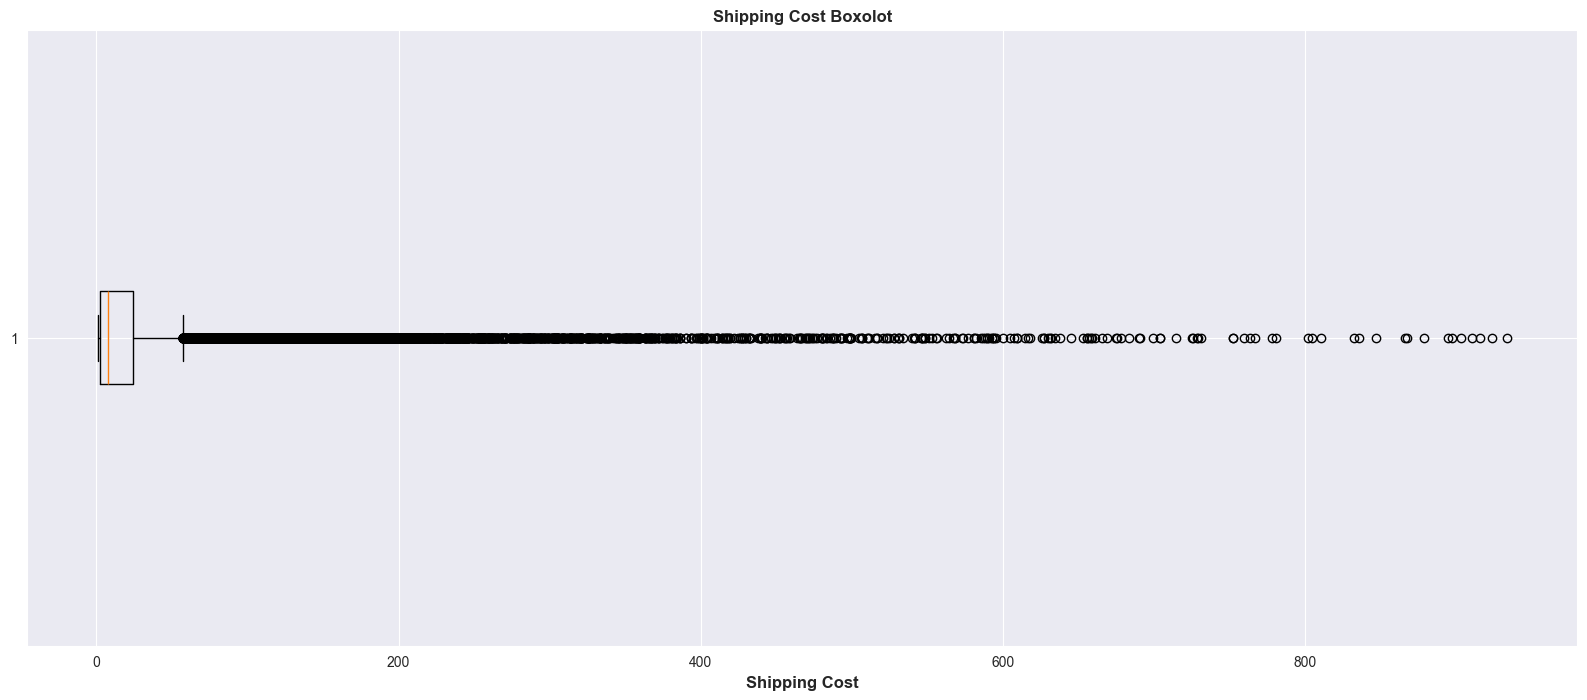

In [18]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Shipping Cost'],vert=False)
plt.title('Shipping Cost Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Cost', fontsize=12, fontweight='bold')
plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển rất rẻ
- Xuất hiện nhiều outliers -> Nhiều đơn hàng có chi phí vận chuyển đột biến. Điều này có thể rơi vào:
    + Đơn hàng quốc tế
    + Hàng hóa cồng kềnh
    + Giao hàng hỏa tốc

-> Kết hợp với biểu đồ lợi nhuận bên trên thì dải chi phí vận chuyển tăng cao này là nguyên nhân nhiều đơn hàng có lỗ lớn

In [19]:
od1 = od.drop(columns=['Row ID', 'Postal Code'])
od1.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost,Year,Month
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2014-05-11 21:26:49.155780,2014-05-15 20:42:42.745174,246.490685,3.476545,0.142908,28.610970,26.478567,2013.777208,7.516027
min,2012-01-01 00:00:00,2012-01-03 00:00:00,0.440000,1.000000,0.000000,-6599.980000,1.002000,2012.000000,1.000000
25%,2013-06-19 00:00:00,2013-06-23 00:00:00,30.762500,2.000000,0.000000,0.000000,2.610000,2013.000000,5.000000
50%,2014-07-08 00:00:00,2014-07-12 00:00:00,85.055000,3.000000,0.000000,9.240000,7.790000,2014.000000,8.000000
75%,2015-05-22 00:00:00,2015-05-26 00:00:00,251.055000,5.000000,0.200000,36.810000,24.450000,2015.000000,10.000000
max,2015-12-31 00:00:00,2016-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.980000,933.570000,2015.000000,12.000000
std,NaN,NaN,487.565388,2.278766,0.212280,174.341066,57.251373,1.098931,3.300526


BẢNG THỐNG KÊ MÔ TẢ


 Quantity:
 - Trung bình 3-4 sản phẩm/đơn
-> Đơn hàng nhỏ lẻ

Discount:
 - Trung bình là ~14% nhưng median = 0 -> Phần lớn đơn hàng không có giảm giá
 - Nhưng max = 85% -> Sẽ có nhưng đơn hàng giảm giá rất cao

Shipping Cost:
 - Trung bình ~26 nhưng median chỉ ~7.8 -> Dữ liệu lệch phải
 - Max = 933 -> Đơn hàng cho chi phí vận chuyển bất thường


In [20]:
od.describe(include=['object', 'string'])

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25728,4,17415,796,3,3650,1102,165,23,5,3788,3,17,3788,4
top,CA-2015-SV20365140-42268,Standard Class,SV-203651406,Muhammed Yedwab,Consumer,New York City,California,United States,Western Europe,Asia Pacific,OFF-FA-6129,Office Supplies,Binders,Staples,Medium
freq,14,30775,26,108,26518,915,2001,9994,5883,14302,227,31289,6146,227,29433


BẢNG THỐNG KÊ NHANH CÁC CỘT DẠNG CHỮ
- Unique lớn -> Khách hàng & sản phẩm đa dạng
- Consumer là nhóm khách chính ( top + freq cao)
- Standard Class là cách giao hàng phổ biến
- Office Supplies là ngành hàng bán được nhiều nhất
- United States là thị trường lớn nhất.

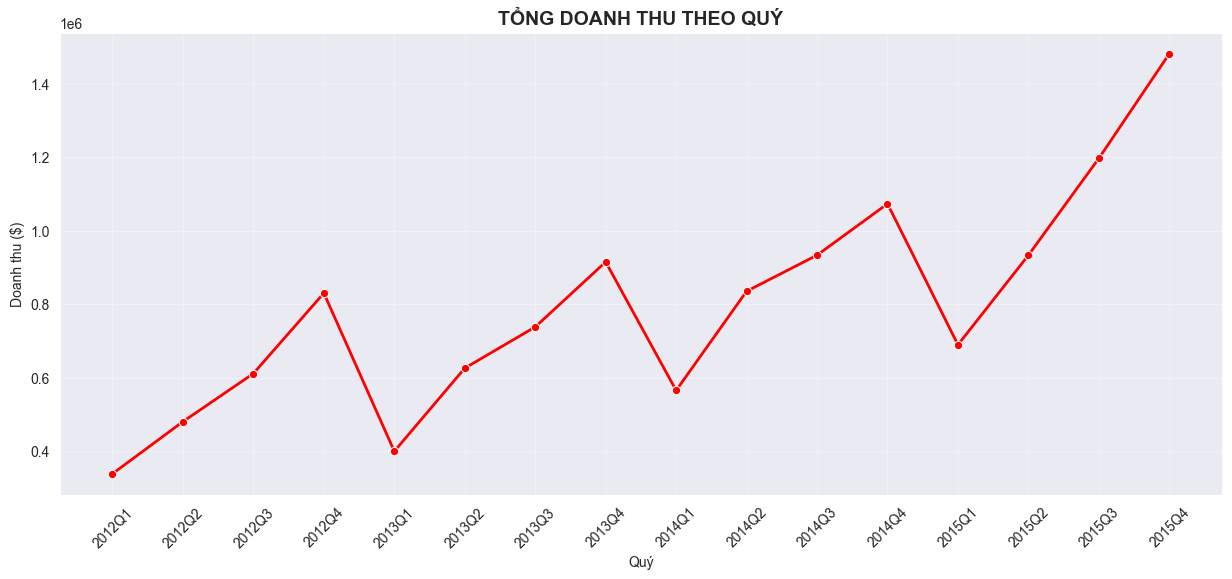

In [21]:
od['Quarter'] = od['Order Date'].dt.to_period('Q').astype(str)
df_quy = od.groupby('Quarter')['Sales'].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_quy, x='Quarter', y='Sales', marker='o', color='red', linewidth=2)
plt.title('TỔNG DOANH THU THEO QUÝ', fontsize=14, fontweight='bold')
plt.xlabel('Quý')
plt.ylabel('Doanh thu ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

- Tổng doanh thu có sự đi lên rõ rột qua các năm 2012 đến 2015 ( Từ 400k  đến  1.5M )
- Doanh thu luôn sụt giảm mạnh vào quý 1 hằng năm và tăng vọt vào quý 4 ( vì cuối năm thường sẽ có các sự kiến mua sắm lớn như Black Friday, Giáng sinh, Năm mới )

-> BIỂU ĐỒ DOANH THU THEO QUÝ GIAI ĐOẠN 2012 - 2015 CHO THẤY SỰ TĂNG TRƯỞNG TÍCH CỰC VỀ QUY MÔ. HOẠT ĐỘNG KINH DOANH MANG TÍNH MÙA VỤ VỚI ĐỈNH DOANH THU RƠI VÀO CUỐI NĂM. ĐÂY LÀ CƠ SỞ ĐỂ DOANH NGHIỆP LẬP KẾ HOẠCH DỰ TRỮ HÀNG HÓA VÀ CHUẨN BỊ NHÂN SỰ CHO CÁC GIAI ĐOẠN CAO Đ

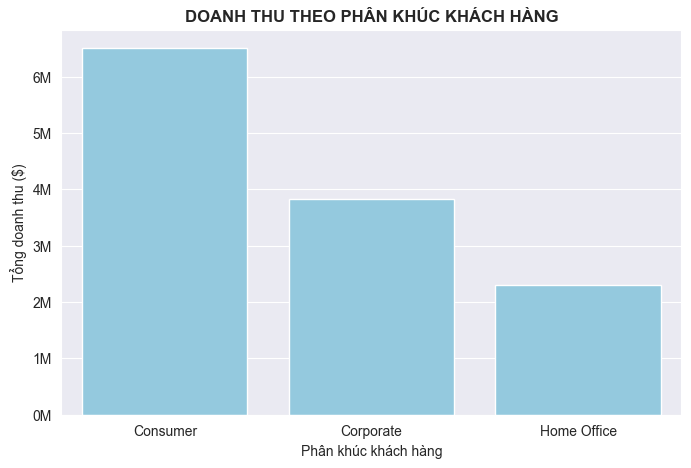

In [22]:
segment_revenue = od.groupby('Segment')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_revenue, x='Segment', y='Sales', color='skyblue')
plt.title('DOANH THU THEO PHÂN KHÚC KHÁCH HÀNG', fontsize=12, fontweight='bold')
plt.xlabel('Phân khúc khách hàng')
plt.ylabel('Tổng doanh thu ($)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))
plt.show()

- Consumer đóng góp doanh thu cao nhất ( vượt 6M USD). Điều này cho thấy việc kinh doanh đang tập trung mạnh vào bán lẻ cá nhân tuy nhiên có sự mất cân bằng so với 2 nhóm còn lại là Corporate và Home Office

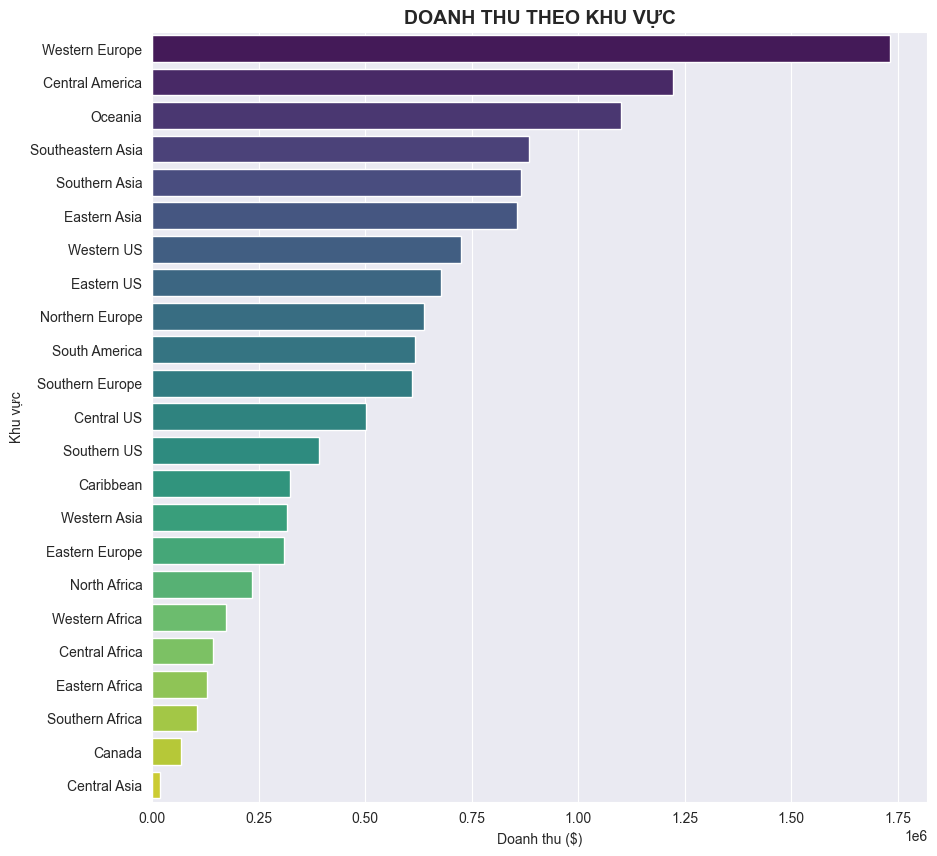

In [23]:
region_sales = od.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(data=region_sales, x='Sales', y='Region', palette='viridis', hue='Region')
plt.title('DOANH THU THEO KHU VỰC', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Khu vực')
plt.show()

- Khu vực Western Europe (Tây Âu) mang lại doanh thu cao nhất (gần 1.75M USD) cách khá xa 2 khu vực sau là Central American và Oceania. Cho thấy đây là những thị trường ổn định và có sức mua cao trong hệ thống
- Các khu vực thuộc châu Á đang nằm ở nhóm giữa, cho thấy cơ hội thâm nhập vào thị trường này dang ổn định và có khả năng trở thành trụ cột trong tương lai
- Sự chênh lệnh giữa nhóm đầu và nhóm cuối, điều này cho thấy sự phát triển không đồng đều giữa các thị trường trên toàn cầu
- Doanh thu thấp ở khu vực Canada nằm tại khu vực châu Mĩ cho thấy có thể có rào cản về logistic, sự cạnh tranh nội địa tại khu vực này
- Doanh thu tại Mỹ bị chia nhỏ thành nhiều vùng khiến cho thị trường này trên biểu đồ trông có vẻ thấp hơn so với thực tế tổng thể.

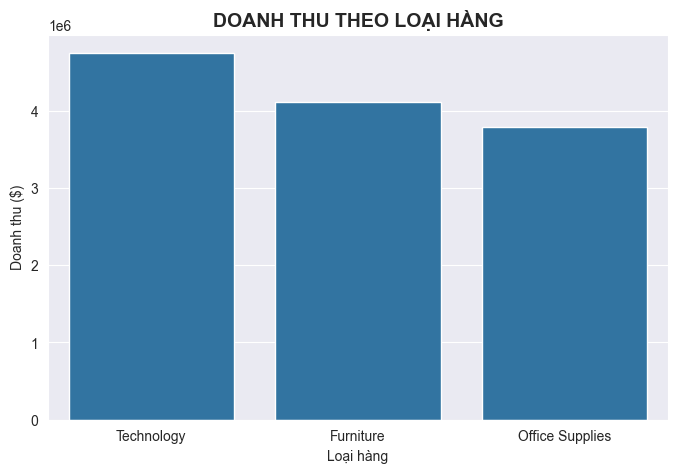

In [24]:
category_sales = od.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title('DOANH THU THEO LOẠI HÀNG', fontsize=14, fontweight='bold')
plt.xlabel('Loại hàng')
plt.ylabel('Doanh thu ($)')
plt.show()

- Doanh thu giữa 3 nhóm ngành hàng khá đồng đều (khoảng từ 3.7M - 4.7M USD)
- Hàng Technology (Công nghệ) chiếm doanh thu cao nhất phản ánh xu hướng thị trường khi các sản phẩm công nghệ thường có đơn giá cao và nhu cầu lớn trên quy mô toàn cầu.
- Ngành hàng Furniture (Nội thất) đứng thứ hai với doanh thu hơn 4.1 triệu USD. Tuy nhiên, đây là nhóm hàng đặc thù thường có chi phí vận chuyển và tỷ lệ hoàn trả cao, nên doanh thu lớn chưa chắc đã đi kèm với lợi nhuận cao nhất
- Nhóm ngành Office Supplies (Văn phòng phẩm) đứng thứ cuối nhưng đây thường là nhóm có số lượng đơn hàng lớn nhất. Các mặt hàng này giúp doanh nghiệp duy trì lượng khách hàng trung thành và lượt mua sắm lặp lại thường xuyên.

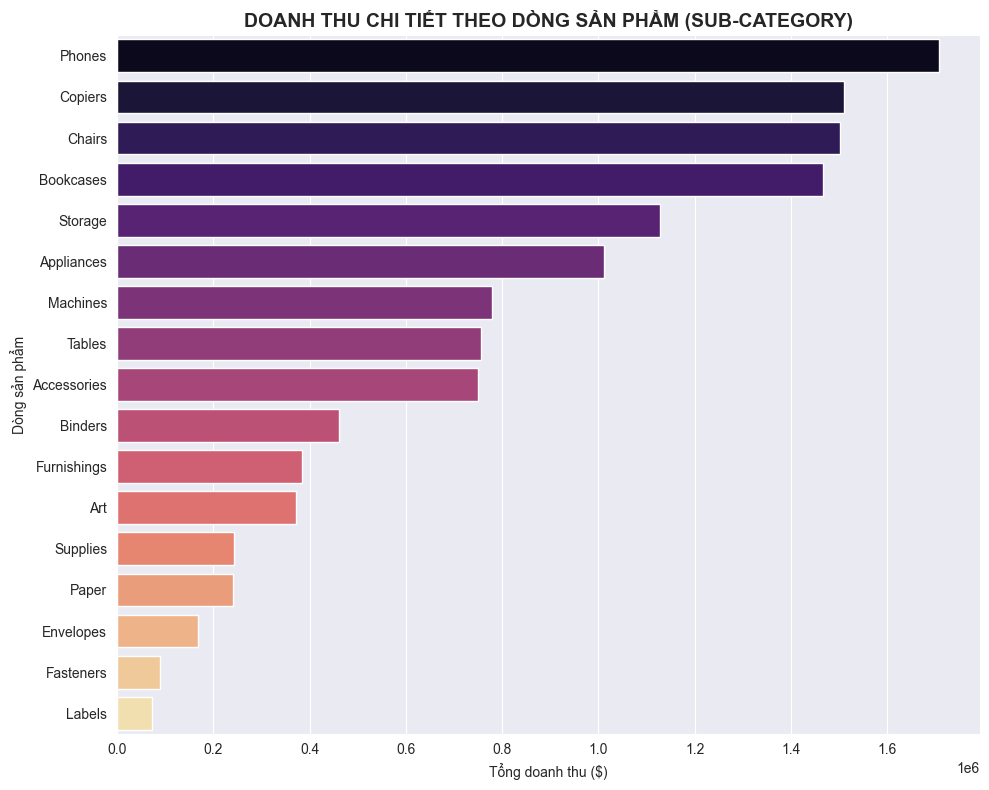

In [25]:
sub_cat_revenue = od.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=sub_cat_revenue, x='Sales', y='Sub-Category', palette='magma',hue='Sub-Category')

plt.title('DOANH THU CHI TIẾT THEO DÒNG SẢN PHẨM (SUB-CATEGORY)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng doanh thu ($)')
plt.ylabel('Dòng sản phẩm')

plt.tight_layout()
plt.show()

- Phones và Copiers là hai dòng sản phẩm mang lại doanh thu lớn nhất (đều vượt ngưỡng 1.5 triệu USD). Điều này khẳng định nhóm hàng Technology dẫn đầu là nhờ các thiết bị điện tử có giá trị đơn hàng cao.
- Nhóm nội thất đóng góp khá đáng kể (Chairs, Bookcases, Tables) cho thấy nhu cầu về trang bị văn phòng và nhà ở cao
- Có một sự tương phản rõ rệt giữa nhóm đầu và nhóm cuối. Trong khi Phones mang về hàng triệu USD, thì các dòng như Labels (Nhãn dán) hay Fasteners (Kẹp/Ghim) có doanh thu cực thấp. Điều này cho thấy chiến lược doanh thu của công ty dựa trên các sản phẩm giá trị cao thay vì các mặt hàng phụ kiện nhỏ lẻ.

Doanh thu và lợi nhuận theo dòng sản phẩm

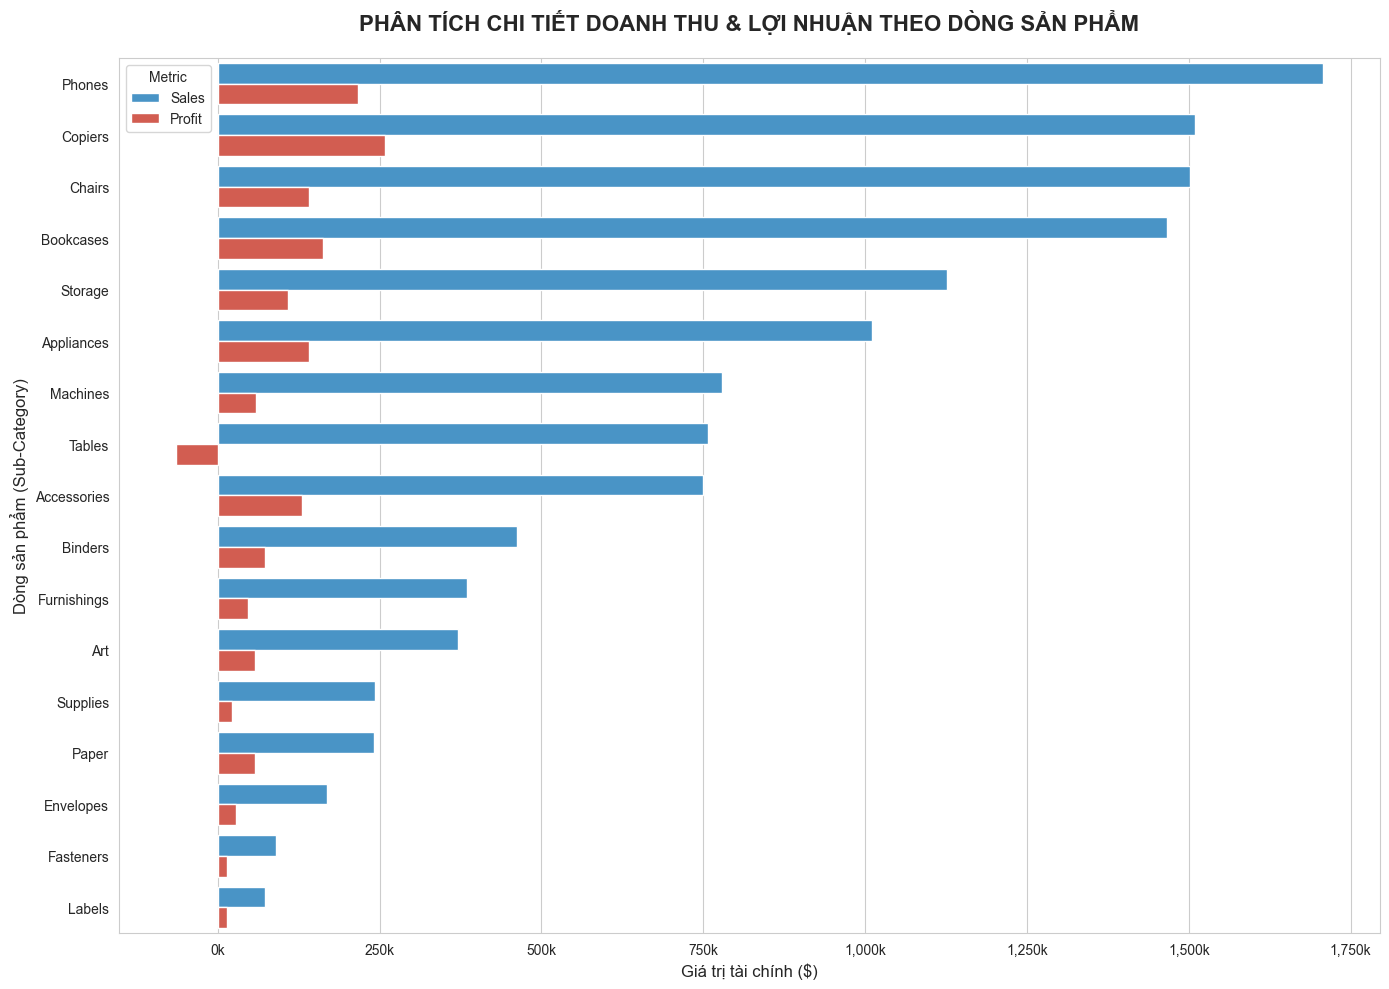


Bảng thống kê chi tiết:
Sub-Category      Sales    Profit  Profit_Margin_%
       Paper  241787.67  58111.27        24.034009
      Labels   73350.55  14988.80        20.434475
 Accessories  749237.28 129626.44        17.301120
     Copiers 1509436.51 258567.63        17.130077
   Envelopes  169217.58  28849.26        17.048619
     Binders  461870.09  72432.92        15.682531
         Art  371613.70  57829.90        15.561832
   Fasteners   89495.19  13844.08        15.469077
  Appliances 1010535.76 141562.63        14.008671
      Phones 1706824.65 216717.44        12.697112
 Furnishings  385156.15  46845.56        12.162745
   Bookcases 1466572.55 161924.37        11.041006
     Storage 1126813.78 108416.94         9.621549
      Chairs 1501682.16 140396.24         9.349265
    Supplies  242811.14  22559.04         9.290776
    Machines  779060.32  58867.70         7.556244
      Tables  757042.17 -64083.55        -8.464991


In [26]:
analysis = od.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()
analysis = analysis.sort_values('Sales', ascending=False)
melted_df = analysis.melt(id_vars='Sub-Category', var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
plot = sns.barplot(data=melted_df, x='Value', y='Sub-Category', hue='Metric', palette=['#3498db', '#e74c3c'])
plt.title('PHÂN TÍCH CHI TIẾT DOANH THU & LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Giá trị tài chính ($)', fontsize=12)
plt.ylabel('Dòng sản phẩm (Sub-Category)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}k".format(x/1e3)))
plt.tight_layout()
plt.show()
analysis['Profit_Margin_%'] = (analysis['Profit'] / analysis['Sales']) * 100
print("\nBảng thống kê chi tiết:")
print(analysis.sort_values('Profit_Margin_%', ascending=False)
      [['Sub-Category', 'Sales', 'Profit', 'Profit_Margin_%']]
      .to_string(index=False))

- Từ bảng thống kê có thể thấy rõ sự khác biệt giữa doanh thu và phần trăm lợi nhuận của các nhóm sản phẩm
- Một số nhóm sản phẩm như Paper và Labels có phần trăm lợi nhuận cao (24% và 20%) cho thấy khả năng kiểm soát chi phí tốt và mang lại hiệu quả kinh doanh cao. Bên cạnh đó Copier là nhóm sản phẩm nổi bật khi vừa đạt doanh thu cao và lợi nhuận cao
- Phones, Chairs, Storage là các nhóm sản phẩm có doanh thu cao nhưng phần trăm lợi nhuận lại thấp. Điều này cho thấy doanh nghiệp chưa có những chính sách giá tối ưu đối với sản phẩm này
- Đáng chú ý là nhóm Tables có phần trăm lợi nhuận âm (-8.46%) tức là đang kinh doanh thua lỗ. Đây là dấu hiệu cực kì báo động, doanh nghiệp cần xem xét lại chi phí, giá bán và chiến lược kinh do

So sánh mức giảm giá và tỷ suất lợi nhuận.

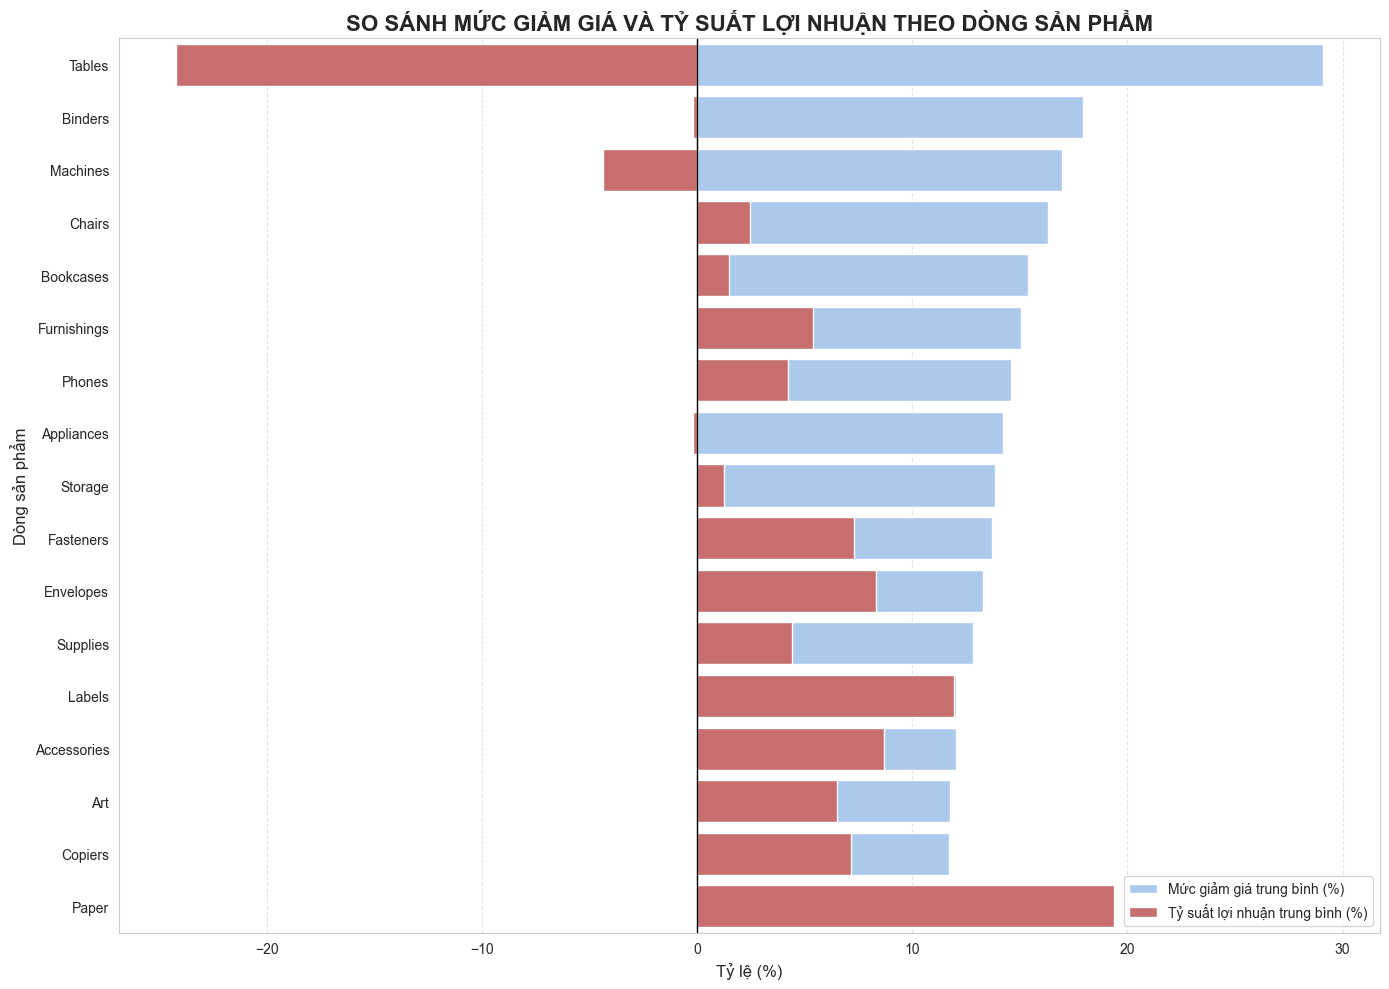


BẢNG THỐNG KÊ CHI TIẾT:
Sub-Category  Discount_%  Profit_Margin_%
      Tables   29.073171       -24.204800
     Binders   17.928409        -0.172981
    Machines   16.958277        -4.350493
      Chairs   16.311008         2.477528
   Bookcases   15.375778         1.488165
 Furnishings   15.062777         5.390950
      Phones   14.584748         4.213040
  Appliances   14.207807        -0.198507
     Storage   13.854031         1.261661
   Fasteners   13.719339         7.312973
   Envelopes   13.289066         8.292237
    Supplies   12.804321         4.412333
      Labels   12.052672        11.930966
 Accessories   12.048130         8.705600
         Art   11.757401         6.485630
     Copiers   11.714710         7.167309
       Paper   11.010882        19.371858


In [27]:
od['Profit_Margin_%'] = (od['Profit'] / od['Sales']) * 100
analysis = od.groupby('Sub-Category').agg({
    'Discount': 'mean',
    'Profit_Margin_%': 'mean'
}).reset_index()
analysis['Discount_%'] = analysis['Discount'] * 100
analysis = analysis.sort_values('Discount_%', ascending=False)
plt.figure(figsize=(14, 10))
sns.set_color_codes("pastel")
sns.barplot(x="Discount_%", y="Sub-Category", data=analysis,
            label="Mức giảm giá trung bình (%)", color="b")
sns.set_color_codes("muted")
sns.barplot(x="Profit_Margin_%", y="Sub-Category", data=analysis,
            label="Tỷ suất lợi nhuận trung bình (%)", color="r")
plt.axvline(0, color='black', lw=1)
plt.title('SO SÁNH MỨC GIẢM GIÁ VÀ TỶ SUẤT LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold')
plt.xlabel('Tỷ lệ (%)', fontsize=12)
plt.ylabel('Dòng sản phẩm', fontsize=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("\nBẢNG THỐNG KÊ CHI TIẾT:")
print(analysis[['Sub-Category', 'Discount_%', 'Profit_Margin_%']].to_string(index=False))

- Từ bảng thống kê có thể thấy quan hệ nghịch giữa mức giảm giá (Discount) và tỷ suất lợi nhuận (Profit_Margin) ở nhiều nhóm sản phẩm. Các nhóm có mức discount cao thường đi kèm với lợi nhuận thấp hoặc âm
- Tables có mức discount cao nhất (~29%) nhưng lợi nhuận âm rất lớn (-24%), cho thấy việc giảm giá mạnh khiến cho doanh nghiệp bị thua lỗ
- Binders và Machines cũng có discount cao (>16%) nhưng biên lợi nhuận thấp hoặc gần bằng 0, phản ánh hiệu quả kinh doanh kém
- Chairs và Bookcases cũng có discount tương đối cao ( 15-16%) nhưng lợi nhuận của thấp (~1-2%)
- Ngược lại, Paper có mức discount thấp nhưng tỷ suất lợi nhuận là cao nhất (~19%)

-> Discount đang ảnh hưởng tiêu cực đến lợi nhuận nếu không được kiểm soát hợp lý. Một số nhóm sản phẩm đang lạm dụng chiến lược giảm giá để thúc đẩy doanh thu nhưng làm giảm hiệu quả kinh do

Biểu đồ heatmap: Lợi nhuận theo ngành hàng và khu vực

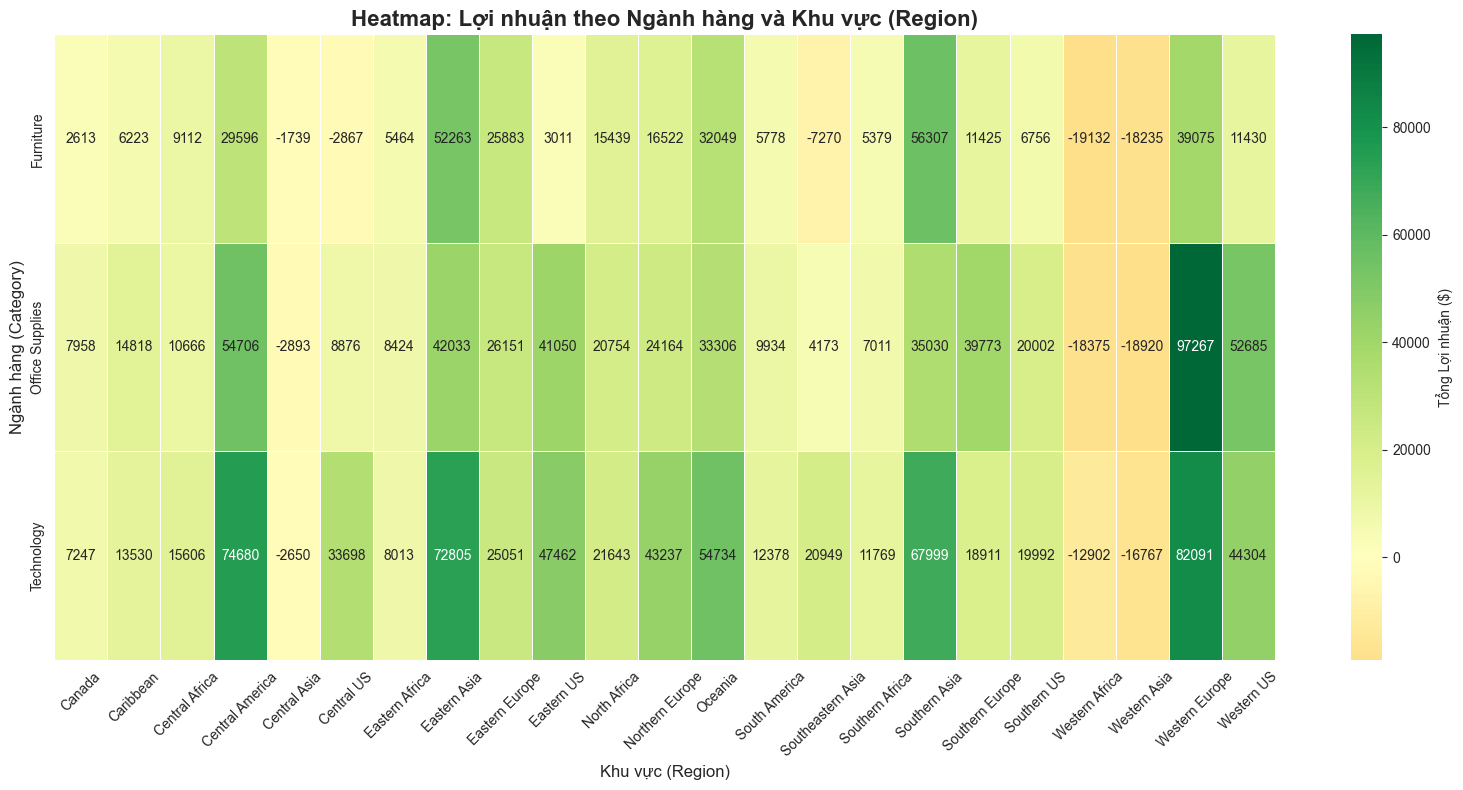


BẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:
           Region      Profit
   Western Europe 218,433.33$
     Eastern Asia 167,101.62$
    Southern Asia 159,336.18$
  Central America 158,981.81$
          Oceania 120,089.66$
       Western US 108,418.69$
       Eastern US  91,522.80$
  Northern Europe  83,923.29$
   Eastern Europe  77,084.88$
  Southern Europe  70,109.35$
     North Africa  57,836.25$
      Southern US  46,749.69$
       Central US  39,706.44$
   Central Africa  35,383.71$
        Caribbean  34,571.35$
    South America  28,090.48$
  Southern Africa  24,158.55$
   Eastern Africa  21,900.87$
Southeastern Asia  17,852.34$
           Canada  17,817.39$
     Central Asia  -7,282.06$
   Western Africa -50,408.25$
     Western Asia -53,921.70$


In [35]:
heatmap_region = od.pivot_table(index='Category',
                                columns='Region',
                                values='Profit',
                                aggfunc='sum')

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_region, annot=True, fmt=".0f", cmap='RdYlGn', center=0,
            linewidths=.5, cbar_kws={'label': 'Tổng Lợi nhuận ($)'})
plt.title('Heatmap: Lợi nhuận theo Ngành hàng và Khu vực (Region)', fontsize=16, fontweight='bold')
plt.xlabel('Khu vực (Region)', fontsize=12)
plt.ylabel('Ngành hàng (Category)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
region_profit_summary = od.groupby('Region')['Profit'].sum().reset_index()
# 3. Sắp xếp từ Lãi cao nhất đến Lỗ nặng nhất
region_profit_summary = region_profit_summary.sort_values('Profit', ascending=False)
print("\nBẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:")
print(region_profit_summary.to_string(
    formatters={'Profit': '{:,.2f}$'.format}
))

- Lợi nhuận có sự phân hóa rõ rệt giữa các khu vực và ngành hàng
- Lãi cao tập trung chủ yếu ở ngành hàng Technology và Office Supplies tại các thị trường phát triển
- Ngành hàng Furniture chịu lỗ nhiều nhất, đặc biệt tại khu vực Western Africa( -19132$) và  Western Asia(-18235$). Đây cũng là 2 khu vực lỗ nặng nhất ở cả 3 ngành hàng. Furniture thường có kích thước lớn, nặng. Nếu bán ở những vùng có cơ sở hạ tầng giao thông chưa phát triển hoặc địa hình phức tạp, phí giao hàng sẽ "ngốn" sạch lợi nhuận.
- Western Europe và Eastern Asia ( điển hình như Trung Quốc, Nhật Bản, Hàn Quốc, Anh, Pháp, Đức) và 2 khu vực có lợi nhuận cao nhất. Đây là những thị trường có nền kinh tế lớn mạnh, khách hàng sẵn sàng chi trả cho những sản phẩm có giá trị cao.